## Tumor Diagnosis with Linear SVM (SGD + 5-fold CV)

Scikit-Learn: https://scikit-learn.org/stable/

In [1]:
# Imports
import numpy as np
import matplotlib.pyplot as plt # for plotting 
import seaborn as sns # for plotting
from sklearn import datasets
from sklearn import preprocessing
from sklearn import linear_model
from sklearn import model_selection as ms

In [2]:
cancer_data = datasets.load_breast_cancer()
y = cancer_data.target # Training labels ('malignant = 0', 'benign = 1')
X = cancer_data.data # 30 attributes; https://scikit-learn.org/stable/datasets/index.html#breast-cancer-dataset
X = preprocessing.scale(X) # scale each data attribute to zero-mean and unit variance 

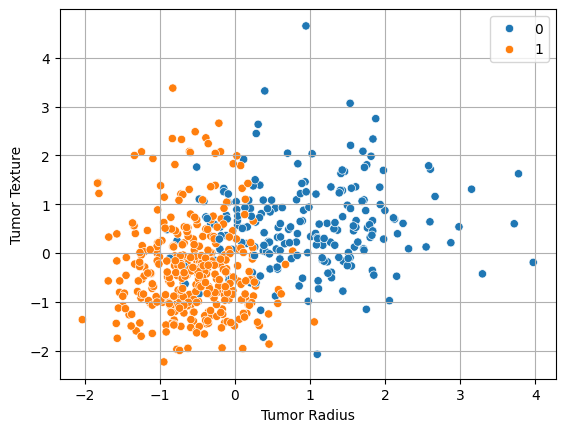

In [3]:
# Plot the first 2 attributes of training points
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y)
plt.xlabel('Tumor Radius')
plt.ylabel('Tumor Texture')
plt.grid(True)
plt.show()

In [4]:
# Cross Validation (CV)
alpha = np.arange(1e-15,1,0.005) # Range of hyperparameter values 1E-15 to 1 by 0.005
val_scores = np.zeros(len(alpha)) # Initialize validation score for each alpha value

for i in range(len(alpha)): # for each alpha value
    # Set up SVM with hinge loss and l2 norm regularization
    model = linear_model.SGDClassifier(loss='hinge', penalty='l2', alpha=alpha[i])
    # Calculate cross validation scores (accuracies) for 5-fold cross-validation
    score = ms.cross_val_score(model, X, y, cv=5) # Split data into 5 folds; fit on 4/5 and validate on 1/5 (repeated 5 times); returns 5 accuracies
    val_scores[i] = score.mean() # Calculate mean of the 5 scores (accuracies)

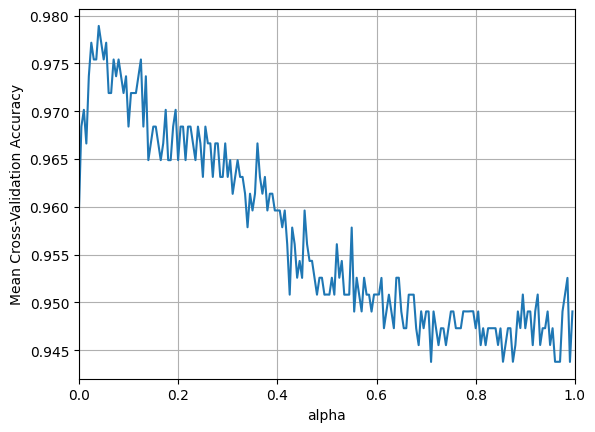

In [5]:
# Plot how cross-validation score changes with alpha
plt.plot(alpha,val_scores)
plt.xlim(0,1)
plt.xlabel('alpha')
plt.ylabel('Mean Cross-Validation Accuracy')
plt.grid(True)
plt.show()

alpha_star = 0.040000000000001


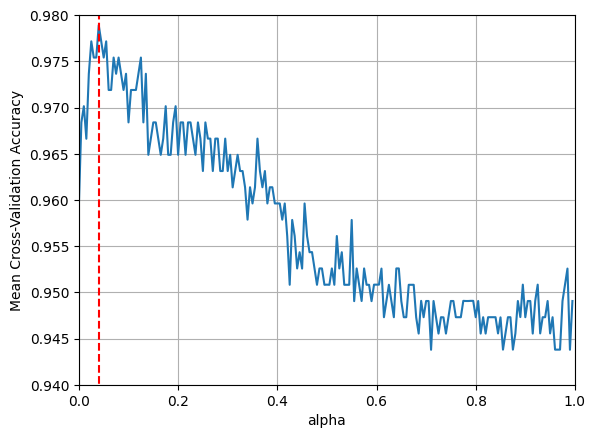

In [6]:
# Determine the alpha that maximizes the cross-validation score
ind = np.argmax(val_scores)
alpha_star = alpha[ind]
print('alpha_star =', alpha_star)

plt.plot(alpha,val_scores)
plt.plot(np.ones(11)*alpha_star,np.arange(0,1.1,0.1),'--r')
plt.xlim(0,1)
plt.ylim(0.94,0.98)
plt.xlabel('alpha')
plt.ylabel('Mean Cross-Validation Accuracy')
plt.grid(True)
plt.show()

In [7]:
# Train model with alpha_star
model_star = linear_model.SGDClassifier(loss='hinge', penalty='l2', alpha=alpha_star)
model_trained = model_star.fit(X,y)
print('Training Accuracy =', model_trained.score(X,y))
# Training Accuracy = 98% (approximately)

Training Accuracy = 0.984182776801406


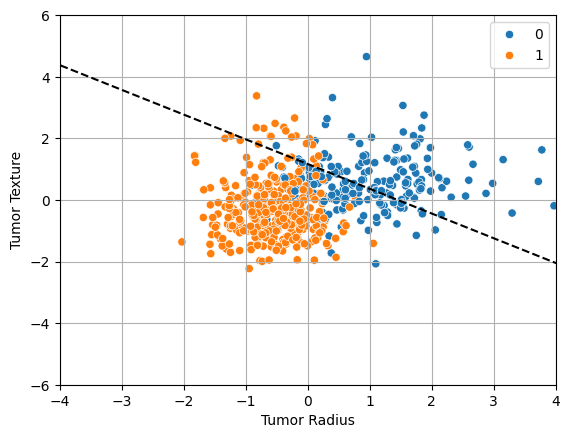

In [8]:
# Plot decision boundary of trained model (in 2D)
# Slice the linear classifier plane equation in 2D by setting X[:,2], ..., X[:,29] = 0 
slope = -model_trained.coef_[0,0]/model_trained.coef_[0,1]
intercept = -model_trained.intercept_[0]/model_trained.coef_[0,1]
x1 = np.arange(-10,10,0.5)
y1 = slope*x1 + intercept
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y)
plt.plot(x1,y1,'--k')
plt.xlim(-4,4)
plt.ylim(-6,6)
plt.xlabel('Tumor Radius')
plt.ylabel('Tumor Texture')
plt.grid(True)
plt.show()